# HPO por perfil — búsqueda conjunta de hiperparámetros

Una fase independiente por perfil de riesgo.  
Cada fase busca simultáneamente hiperparámetros de entrenamiento (`tau`, `lr_actor`, `lr_criticos`)  
y lambdas del entorno (`lambda_dd`, `lambda_varianza`, `lambda_correlacion`).  
El perfil `riesgo` está fijo desde el inicio de cada búsqueda, sin mezcla entre perfiles.

Al finalizar las 5 fases se ejecuta una verificación cruzada de jerarquía CAGR.

**Pasos de entrenamiento por run:** 50 000  
**Combinaciones por perfil:** 16 (grid 2×2×2×2, lambdas)  
**Runs totales:** 80

## Imports y utilidades

In [1]:
from __future__ import annotations

import os
import sys
import copy
import json
import time
import random
import inspect
from itertools import product
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from Entrenamiento_SAC import ConfigEntrenamiento, entrenar_sac
from entorno_cartera import EntornoCartera

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"PyTorch: {torch.__version__}")
print(f"MPS disponible: {torch.backends.mps.is_available()}")

PROJECT_ROOT: /Users/inigo/Optimizaci-n-din-mica-de-carteras-mediante-Deep-Reinforcement-Learning
PyTorch: 2.10.0
MPS disponible: True


In [2]:
def fijar_semillas(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def encontrar_carpeta_datos() -> Path:
    candidatos = [
        PROJECT_ROOT / "Datos",
        PROJECT_ROOT / "datos",
        PROJECT_ROOT / "datos_procesados",
    ]
    for carpeta in candidatos:
        if carpeta.exists():
            return carpeta
    raise FileNotFoundError("No encuentro la carpeta de datos. Revisa PROJECT_ROOT.")


def cargar_split(carpeta_base: Path, nombre_split: str):
    carpeta_split = carpeta_base / nombre_split.capitalize()
    datos_estado = pd.read_csv(
        carpeta_split / f"datos_estado_{nombre_split}.csv",
        index_col=0, parse_dates=True,
    )
    retornos = pd.read_csv(
        carpeta_split / f"retornos_{nombre_split}.csv",
        index_col=0, parse_dates=True,
    )
    rf_semanal = pd.read_csv(
        carpeta_split / f"rf_semanal_{nombre_split}.csv",
        index_col=0, parse_dates=True,
    ).squeeze("columns")
    return datos_estado, retornos, rf_semanal


def moving_average(x, window=50):
    x = np.asarray(x, dtype=float)
    if window is None or window <= 1 or len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")

## Carga de datos

In [3]:
carpeta_datos = encontrar_carpeta_datos()

datos_estado_train, retornos_train, rf_semanal_train = cargar_split(carpeta_datos, "train")
datos_estado_val,   retornos_val,   rf_semanal_val   = cargar_split(carpeta_datos, "validation")

cov_train = pd.read_csv(carpeta_datos / "Train"      / "covarianzas_train.csv",      index_col=0)
cov_val   = pd.read_csv(carpeta_datos / "Validation" / "covarianzas_validation.csv", index_col=0)

print(f"Carpeta datos: {carpeta_datos}")
print(f"Train:      {datos_estado_train.shape}  retornos: {retornos_train.shape}")
print(f"Validation: {datos_estado_val.shape}  retornos: {retornos_val.shape}")
print(f"Cov train: {cov_train.shape} | Cov val: {cov_val.shape}")

Carpeta datos: /Users/inigo/Optimizaci-n-din-mica-de-carteras-mediante-Deep-Reinforcement-Learning/Datos
Train:      (679, 144)  retornos: (679, 16)
Validation: (209, 144)  retornos: (209, 16)
Cov train: (16, 16) | Cov val: (16, 16)


## Configuración global y perfiles

In [4]:
# ------------------------------------------------------------------
# PERFILES
# ------------------------------------------------------------------
PERFILES_RIESGO: Dict[str, float] = {
    "muy_conservador": 0.10,
    "conservador":     0.30,
    "normal":          0.50,
    "arriesgado":      0.70,
    "muy_arriesgado":  0.90,
}

# ------------------------------------------------------------------
# CONFIG BASE — fija para todos los perfiles
# Valores procedentes del HPO anterior (Fase A ganadora)
# ------------------------------------------------------------------
BASE_CONFIG: Dict[str, Any] = {
    "semilla":                      43,
    "pasos_totales":                100_000,        # reducido de 200k
    "tamano_buffer":                50_000,
    "tamano_batch":                 256,
    "pasos_warmup":                 1_000,         # escalado con pasos_totales
    "gamma":                        0.99,          
    "lr_alpha":                     1e-4,
    "frecuencia_actualizacion":     2,
    "actualizaciones_por_step":     2,
    "reward_scale":                 20.0,
    "target_entropy":               -8.0,
    "offset_target_entropy":        0.0,
    "max_concentracion_total_extra": 5.0,
    "ventana_log_recompensa":       500,
    "frecuencia_log":               5_000,
    "frecuencia_snapshot_cartera":  5_000,
}

# ------------------------------------------------------------------
# CONTROL
# ------------------------------------------------------------------
SEED_BASE       = 43
TOP_K           = 3

N_ACTIVOS_TOTALES         = retornos_train.shape[1] + 1
cartera_inicial_validacion = np.ones(N_ACTIVOS_TOTALES) / N_ACTIVOS_TOTALES

print(f"N_ACTIVOS_TOTALES: {N_ACTIVOS_TOTALES}")
print(f"Pasos de entrenamiento: {BASE_CONFIG['pasos_totales']:,}")
print(f"Perfiles: {list(PERFILES_RIESGO.keys())}")

N_ACTIVOS_TOTALES: 17
Pasos de entrenamiento: 100,000
Perfiles: ['muy_conservador', 'conservador', 'normal', 'arriesgado', 'muy_arriesgado']


## Espacios de búsqueda por perfil

Cada perfil tiene su propio grid.  
Los perfiles conservadores buscan lambdas altos (penalizan más el riesgo).  
Los perfiles arriesgados buscan lambdas bajos (permiten más volatilidad).  
`tau` y `lr_actor` / `lr_criticos` se buscan igual en todos.

Grid por perfil: 2 (tau) × 2 (lr_actor) × 2 (lr_criticos) × 2 (lambda_dd) = **16 combinaciones**.

In [5]:
# Hiperparámetros de entrenamiento — iguales en todos los perfiles
_TRAIN_HPS: Dict[str, List] = {
    "tau":         [0.02, 0.05],
    "lr_actor":    [1e-4, 3e-4],
    "lr_criticos": [3e-4],
}

# Lambdas específicos por perfil
_LAMBDAS_POR_PERFIL: Dict[str, Dict[str, List]] = {
    "muy_conservador": {
        #"lambda_dd":          [0.20, 0.40],
        "lambda_varianza":    [0.25, 0.40, 0.55],
        "lambda_correlacion": [0.10],
    },
    "conservador": {
        #"lambda_dd":          [0.20, 0.40],
        "lambda_varianza":    [0.15, 0.25, 0.35],
        "lambda_correlacion": [0.10],
    },
    "normal": {
        #"lambda_dd":          [0.20, 0.40],
        "lambda_varianza":    [0.15, 0.25, 0.35],
        "lambda_correlacion": [0.10],
    },
    "arriesgado": {
        #"lambda_dd":          [0.10, 0.20],
        "lambda_varianza":    [0.08, 0.12, 0.18, 0.25],
        "lambda_correlacion": [0.05],
        "tau":                [0.02, 0.03],  # más agresivo
    },
    "muy_arriesgado": {
        #"lambda_dd":          [0.05, 0.10],
        "lambda_varianza":    [0.02, 0.05, 0.08],
        "lambda_correlacion": [0.02],
    },
}

def espacios_busqueda(perfil: str) -> Dict[str, List]:
    """Une los hiperparámetros de entrenamiento con los lambdas del perfil."""
    espacio = copy.deepcopy(_TRAIN_HPS)
    espacio.update(_LAMBDAS_POR_PERFIL[perfil])
    return espacio

# Mostrar número de combinaciones
for perfil in PERFILES_RIESGO:
    esp = espacios_busqueda(perfil)
    n = int(np.prod([len(v) for v in esp.values()]))
    print(f"  {perfil:20s}: {n} combinaciones  ({list(esp.keys())})")

total_runs = sum(
    int(np.prod([len(v) for v in espacios_busqueda(p).values()]))
    for p in PERFILES_RIESGO
)
segundos_por_run = 540   # estimación M5 con MPS a 100k pasos
horas_estimadas  = total_runs * segundos_por_run / 3600
print(f"\nTotal runs: {total_runs}")
print(f"Tiempo estimado M5 (MPS): {horas_estimadas:.1f} h  (~{horas_estimadas*60:.0f} min)")

  muy_conservador     : 12 combinaciones  (['tau', 'lr_actor', 'lr_criticos', 'lambda_varianza', 'lambda_correlacion'])
  conservador         : 12 combinaciones  (['tau', 'lr_actor', 'lr_criticos', 'lambda_varianza', 'lambda_correlacion'])
  normal              : 12 combinaciones  (['tau', 'lr_actor', 'lr_criticos', 'lambda_varianza', 'lambda_correlacion'])
  arriesgado          : 16 combinaciones  (['tau', 'lr_actor', 'lr_criticos', 'lambda_varianza', 'lambda_correlacion'])
  muy_arriesgado      : 12 combinaciones  (['tau', 'lr_actor', 'lr_criticos', 'lambda_varianza', 'lambda_correlacion'])

Total runs: 64
Tiempo estimado M5 (MPS): 9.6 h  (~576 min)


## Funciones de scoring por perfil

- **muy_conservador / conservador**: priorizan Sharpe y control de drawdown.
- **normal**: optimiza puramente Sharpe.
- **arriesgado / muy_arriesgado**: priorizan CAGR sobre Sharpe.

In [6]:
PESOS_SCORING: Dict[str, Dict[str, float]] = {
    "muy_conservador": {"sharpe": 0.40, "neg_mdd": 0.60, "cagr": 0.00},
    "conservador":     {"sharpe": 0.50, "neg_mdd": 0.50, "cagr": 0.00},
    "normal":          {"sharpe": 0.70, "neg_mdd": 0.10, "cagr": 0.20},
    "arriesgado":      {"sharpe": 0.30, "neg_mdd": 0.10, "cagr": 0.60},
    "muy_arriesgado":  {"sharpe": 0.20, "neg_mdd": 0.00, "cagr": 0.80},
}

# Filtros de cordura por perfil — una config que los viole es descartada del ranking
# pero se mantiene en el resumen (elegible=False) para no romper el pipeline si
# ninguna config pasa (en ese caso se avisa y se usa el resumen completo).
#
# max_dd_max : drawdown máximo tolerable (None = sin límite superior)
# max_dd_min : drawdown mínimo exigido   (None = sin límite inferior)
#              perfiles arriesgados deben mostrar suficiente riesgo
# cagr_min   : CAGR mínimo exigido       (None = sin límite)
FILTROS_PERFIL: Dict[str, Dict] = {
    "muy_conservador": {"max_dd_max": -0.10, "max_dd_min": None,  "cagr_min": None},
    "conservador":     {"max_dd_max": -0.15, "max_dd_min": None,  "cagr_min": None},
    "normal":          {"max_dd_max": -0.25, "max_dd_min": None,  "cagr_min": 0.00},
    "arriesgado":      {"max_dd_max": -0.40, "max_dd_min": -0.03, "cagr_min": 0.05},
    "muy_arriesgado":  {"max_dd_max": None,  "max_dd_min": -0.05, "cagr_min": 0.07},
}


def aplicar_filtros(resumen_df: pd.DataFrame, perfil: str) -> pd.Series:
    """
    Devuelve una Serie booleana (elegible) por fila.

    Reglas:
      max_dd_max : max_drawdown debe ser >= max_dd_max  (menos negativo que el umbral)
                   ej: max_dd_max=-0.10 descarta configs con max_drawdown < -0.10
      max_dd_min : max_drawdown debe ser <= max_dd_min  (más negativo que el umbral)
                   ej: max_dd_min=-0.05 descarta configs con max_drawdown > -0.05
      cagr_min   : cagr debe ser >= cagr_min
    """
    filtros = FILTROS_PERFIL[perfil]
    elegible = pd.Series(True, index=resumen_df.index)

    if filtros["max_dd_max"] is not None:
        elegible &= resumen_df["max_drawdown"] >= filtros["max_dd_max"]

    if filtros["max_dd_min"] is not None:
        elegible &= resumen_df["max_drawdown"] <= filtros["max_dd_min"]

    if filtros["cagr_min"] is not None:
        elegible &= resumen_df["cagr"] >= filtros["cagr_min"]

    n_elegibles = int(elegible.sum())
    n_total     = len(elegible)

    if n_elegibles == 0:
        print(
            f"  ⚠️  [{perfil}] Ninguna config pasa los filtros de cordura "            f"({n_total} configs). Se usa el ranking sin filtrar."
        )
        return pd.Series(True, index=resumen_df.index)  # fallback: no filtrar

    if n_elegibles < n_total:
        print(
            f"  ✂️  [{perfil}] Filtros aplicados: {n_elegibles}/{n_total} configs elegibles."
        )

    return elegible


def calcular_scores_normalizados(
    resumen_df: pd.DataFrame,
    perfil: str,
) -> pd.Series:
    """
    Calcula el score final normalizado para todas las configs de un perfil.

    La normalización min-max se aplica solo sobre las configs ELEGIBLES
    (las que pasan los filtros de cordura). Las no elegibles reciben score=-1
    y quedan al final del ranking.
    """
    pesos    = PESOS_SCORING[perfil]
    elegible = aplicar_filtros(resumen_df, perfil)

    def norm(serie: pd.Series) -> pd.Series:
        """Min-max sobre la serie, ignorando NaN. Empates → 0.5."""
        lo, hi = serie.min(), serie.max()
        if pd.isna(lo) or pd.isna(hi) or hi <= lo:
            return pd.Series(0.5, index=serie.index)
        return ((serie - lo) / (hi - lo)).clip(0.0, 1.0)

    # Normalizar solo sobre el subconjunto elegible para que los outliers
    # descartados no compriman la escala de las configs válidas
    sub = resumen_df[elegible]

    sharpe_n  = norm(sub["sharpe"].fillna(sub["sharpe"].min()))
    neg_mdd_n = norm(sub["max_drawdown"].fillna(sub["max_drawdown"].max()))
    cagr_n    = norm(sub["cagr"].fillna(sub["cagr"].min()))

    score_sub = (
        pesos["sharpe"]  * sharpe_n
        + pesos["neg_mdd"] * neg_mdd_n
        + pesos["cagr"]    * cagr_n
    )

    # Rellenar el score completo: elegibles con su score, no elegibles con -1
    score = pd.Series(-1.0, index=resumen_df.index)
    score[elegible] = score_sub
    return score


## Helpers: entorno, entrenamiento y métricas

In [7]:
def construir_entorno(
    datos_estado: pd.DataFrame,
    retornos: pd.DataFrame,
    rf_semanal: pd.Series,
    riesgo: float,
    cfg: Dict[str, Any],
    covarianzas_iniciales: pd.DataFrame | None = None,
) -> EntornoCartera:
    kwargs = dict(
        datos_estado=datos_estado,
        retornos_semanales=retornos,
        rf_semanal=rf_semanal,
        coste_transaccion=0.001,
        valor_inicial=1_000.0,
        covarianzas_iniciales=covarianzas_iniciales,
        riesgo=float(riesgo),
        lambda_dd=float(cfg.get("lambda_dd", 0.40)),
        lambda_varianza=float(cfg.get("lambda_varianza", 0.30)),
        lambda_correlacion=float(cfg.get("lambda_correlacion", 0.20)),
    )
    return EntornoCartera(**kwargs)


def build_train_config(cfg: Dict[str, Any]) -> ConfigEntrenamiento:
    return ConfigEntrenamiento(
        semilla=int(cfg["semilla"]),
        pasos_totales=int(cfg["pasos_totales"]),
        gamma=float(cfg["gamma"]),
        tau=float(cfg["tau"]),
        lr_actor=float(cfg["lr_actor"]),
        lr_criticos=float(cfg["lr_criticos"]),
        lr_alpha=float(cfg["lr_alpha"]),
        tamano_batch=int(cfg["tamano_batch"]),
        tamano_buffer=int(cfg["tamano_buffer"]),
        pasos_warmup=int(cfg["pasos_warmup"]),
        frecuencia_actualizacion=int(cfg["frecuencia_actualizacion"]),
        actualizaciones_por_step=int(cfg["actualizaciones_por_step"]),
        reward_scale=float(cfg["reward_scale"]),
        target_entropy=(
            None if cfg.get("target_entropy") is None
            else float(cfg["target_entropy"])
        ),
        offset_target_entropy=float(cfg["offset_target_entropy"]),
        max_concentracion_total_extra=float(cfg["max_concentracion_total_extra"]),
        ventana_log_recompensa=int(cfg["ventana_log_recompensa"]),
        frecuencia_log=int(cfg["frecuencia_log"]),
        frecuencia_snapshot_cartera=int(cfg["frecuencia_snapshot_cartera"]),
    )


def politica_determinista(agente, device):
    def fn(estado_np):
        estado_t = torch.as_tensor(
            estado_np, dtype=torch.float32, device=device,
        ).unsqueeze(0)
        with torch.no_grad():
            accion = agente.seleccionar_accion(estado_t, determinista=True)
        return accion.squeeze(0).detach().cpu().numpy().astype(np.float64)
    return fn

In [8]:
def calcular_metricas_financieras(
    valor_cartera: pd.Series,
    rf_semanal: pd.Series,
) -> Dict[str, float]:
    valor_cartera = valor_cartera.astype(float).dropna()
    rend = valor_cartera.pct_change().dropna()

    nan_dict = {k: np.nan for k in [
        "valor_final", "retorno_total", "cagr", "volatilidad_anual",
        "sharpe", "sortino", "max_drawdown", "calmar",
    ]}

    if valor_cartera.empty or len(valor_cartera) < 2 or rend.empty:
        return nan_dict

    rf_alineado = rf_semanal.reindex(rend.index).ffill().fillna(0.0)
    exceso = rend - rf_alineado

    valor_inicial = float(valor_cartera.iloc[0])
    valor_final   = float(valor_cartera.iloc[-1])
    n             = len(rend)
    cagr          = (valor_final / valor_inicial) ** (52 / n) - 1.0
    vol           = rend.std() * np.sqrt(52)
    sharpe        = (
        exceso.mean() / exceso.std() * np.sqrt(52)
        if exceso.std() > 0 else np.nan
    )
    downside = rend[rend < 0]
    sortino  = (
        rend.mean() / downside.std() * np.sqrt(52)
        if len(downside) > 0 else np.nan
    )
    acumulado = (1 + rend).cumprod()
    max_dd    = (acumulado / acumulado.cummax() - 1.0).min()
    calmar    = cagr / abs(max_dd) if max_dd != 0 else np.nan

    return {
        "valor_final":       valor_final,
        "retorno_total":     valor_final / valor_inicial - 1.0,
        "cagr":              cagr,
        "volatilidad_anual": vol,
        "sharpe":            sharpe,
        "sortino":           sortino,
        "max_drawdown":      max_dd,
        "calmar":            calmar,
    }


def evaluar_en_validation(
    agente,
    riesgo: float,
    cfg: Dict[str, Any],
) -> Tuple[pd.Series, Dict[str, float]]:
    device = next(agente.actor.parameters()).device

    entorno_val = construir_entorno(
        datos_estado=datos_estado_val,
        retornos=retornos_val,
        rf_semanal=rf_semanal_val,
        riesgo=riesgo,
        cfg=cfg,
        covarianzas_iniciales=cov_train,  # cov_train evita leakage: la covarianza de validacion no debe conocerse de antemano
    )

    fn_pesos = politica_determinista(agente, device)
    backtest_df = entorno_val.ejecutar_backtest(
        funcion_pesos=fn_pesos,
        pesos_iniciales=cartera_inicial_validacion,
    )

    metricas = calcular_metricas_financieras(
        valor_cartera=backtest_df["valor_cartera"],
        rf_semanal=rf_semanal_val,
    )
    return backtest_df["valor_cartera"], metricas

In [9]:
def train_one_run(
    cfg: Dict[str, Any],
    riesgo: float,
) -> Tuple[Dict, pd.Series, Dict[str, float], Any]:
    """Entrena un run completo y evalúa en validation. Devuelve (history, serie_val, metricas_val, agente)."""
    fijar_semillas(int(cfg["semilla"]))

    entorno_train = construir_entorno(
        datos_estado=datos_estado_train,
        retornos=retornos_train,
        rf_semanal=rf_semanal_train,
        riesgo=riesgo,
        cfg=cfg,
        covarianzas_iniciales=cov_train,
    )

    cfg_train = build_train_config(cfg)

    history, agente = entrenar_sac(
        entorno=entorno_train,
        config=cfg_train,
        devolver_agente=True,
        riesgo=riesgo,
    )

    serie_val, metricas_val = evaluar_en_validation(
        agente=agente,
        riesgo=riesgo,
        cfg=cfg,
    )

    return history, serie_val, metricas_val, agente


def generar_combinaciones(espacios: Dict[str, List]) -> List[Dict[str, Any]]:
    claves = list(espacios.keys())
    return [
        dict(zip(claves, combo))
        for combo in product(*[espacios[k] for k in claves])
    ]


def run_grid_perfil(
    perfil: str,
    riesgo: float,
    verbose: bool = True,
) -> Tuple[pd.DataFrame, Dict[str, pd.Series], Dict[str, Any]]:
    """
    Ejecuta el grid completo para un perfil.
    El score se calcula AL FINAL con normalización min-max por métrica,
    para que Sharpe, neg_MDD y CAGR contribuyan en la misma escala [0,1]
    antes de aplicar los pesos del perfil.
    """
    espacio = espacios_busqueda(perfil)
    combinaciones = generar_combinaciones(espacio)
    n_total = len(combinaciones)

    resumen_rows: List[Dict] = []
    curvas_val:   Dict[str, pd.Series] = {}
    agentes_tmp:  Dict[str, Any] = {}

    t_inicio_perfil = time.time()

    for idx, combo in enumerate(combinaciones, start=1):
        config_id = f"{perfil}_cfg_{idx:03d}"
        cfg = copy.deepcopy(BASE_CONFIG)
        cfg.update(combo)
        cfg["semilla"] = SEED_BASE + idx

        if verbose:
            print("=" * 70)
            print(f"[{perfil}] Config {idx}/{n_total} — {config_id}")
            print("  " + " | ".join(f"{k}={v}" for k, v in combo.items()))

        t0 = time.time()
        try:
            history, serie_val, metricas_val, agente = train_one_run(cfg, riesgo)
        except Exception as e:
            print(f"  ⚠️  ERROR en {config_id}: {e}")
            metricas_val = {k: np.nan for k in ["sharpe", "cagr", "max_drawdown", "volatilidad_anual"]}
            serie_val = pd.Series(dtype=float)
            agente = None
        t1 = time.time()

        curvas_val[config_id] = serie_val
        agentes_tmp[config_id] = agente

        # Guardar métricas brutas — el score se calcula al final
        row = {
            "config_id":    config_id,
            "perfil":       perfil,
            "riesgo":       riesgo,
            "sharpe":       metricas_val.get("sharpe",            np.nan),
            "cagr":         metricas_val.get("cagr",              np.nan),
            "max_drawdown": metricas_val.get("max_drawdown",      np.nan),
            "vol":          metricas_val.get("volatilidad_anual", np.nan),
            "tiempo_s":     round(t1 - t0, 1),
        }
        row.update(combo)
        resumen_rows.append(row)

        if verbose:
            print(
                f"  Sharpe={metricas_val.get('sharpe', np.nan):.4f} | "
                f"CAGR={metricas_val.get('cagr', np.nan):.2%} | "
                f"MDD={metricas_val.get('max_drawdown', np.nan):.2%} | "
                f"tiempo={t1-t0:.0f}s"
            )

    resumen_df = pd.DataFrame(resumen_rows)

    # ── Score normalizado: min-max por métrica, luego ponderar ──────────────
    # Esto garantiza que Sharpe=1.0 y neg_MDD=0.04 pesen igual antes
    # de aplicar los pesos del perfil.
    resumen_df["score"] = calcular_scores_normalizados(resumen_df, perfil)

    resumen_df = resumen_df.sort_values("score", ascending=False).reset_index(drop=True)
    resumen_df["ranking"] = resumen_df.index + 1

    # Conservar solo los agentes top-K para no consumir memoria
    top_ids = set(resumen_df.head(TOP_K)["config_id"].tolist())
    agentes_top = {cid: agentes_tmp[cid] for cid in top_ids if agentes_tmp.get(cid) is not None}

    t_total = time.time() - t_inicio_perfil
    print(f"\n✅ [{perfil}] completado en {t_total/60:.1f} min")

    # Mostrar qué métrica contribuye cuánto al ganador
    espacio = espacios_busqueda(perfil)
    cols_show = ["ranking", "config_id", "score", "sharpe", "cagr", "max_drawdown"] + list(espacio.keys())
    print(resumen_df[cols_show].head(TOP_K).to_string(index=False))

    # Desglose de contribución del score para el ganador
    pesos = PESOS_SCORING[perfil]
    print(f"\nPesos aplicados para '{perfil}': {pesos}")
    print("(score = promedio ponderado de métricas normalizadas en [0,1] dentro del grid)")

    # ── Guardar agente ganador automáticamente en disco ──────────────
    # Esto evita perder el agente si el kernel se reinicia después del HPO.
    best_id     = resumen_df.iloc[0]["config_id"]
    best_agente = agentes_top.get(best_id)
    if best_agente is not None:
        agentes_dir = PROJECT_ROOT / "agentes_ganadores"
        agentes_dir.mkdir(exist_ok=True)
        ruta_pt = agentes_dir / f"agente_{perfil}.pt"
        import torch
        torch.save({
            "actor_state_dict":   best_agente.actor.state_dict(),
            "critic1_state_dict": best_agente.critic1.state_dict(),
            "critic2_state_dict": best_agente.critic2.state_dict(),
            "log_alpha":          best_agente.log_alpha.detach().cpu(),
            "config_id":          best_id,
            "perfil":             perfil,
            "val_sharpe":         float(resumen_df.iloc[0]["sharpe"]),
            "val_cagr":           float(resumen_df.iloc[0]["cagr"]),
            "val_max_drawdown":   float(resumen_df.iloc[0]["max_drawdown"]),
            "dim_estado":         best_agente.actor.obs_dim,
            "dim_accion":         best_agente.actor.act_dim,
        }, ruta_pt)
        print(f"\n💾 Agente guardado: {ruta_pt.name}  "
              f"(Sharpe={resumen_df.iloc[0]['sharpe']:.3f}  "
              f"CAGR={resumen_df.iloc[0]['cagr']:.1%})")
    else:
        print(f"\n⚠️  [{perfil}] No se pudo guardar el agente ganador (None)")

    return resumen_df, curvas_val, agentes_top


---
# Fase 1 — muy_conservador (riesgo = 0.10)

In [10]:
perfil_mc = "muy_conservador"
resumen_mc, curvas_mc, agentes_mc = run_grid_perfil(perfil_mc, PERFILES_RIESGO[perfil_mc])

[muy_conservador] Config 1/12 — muy_conservador_cfg_001
  tau=0.02 | lr_actor=0.0001 | lr_criticos=0.0003 | lambda_varianza=0.25 | lambda_correlacion=0.1
[DIAGNÓSTICO INICIAL]
  mu: min=-2.0270  max=-0.0223  media=-1.8851
  std: min=0.3679  max=0.3679  media=0.3679
  log_prob: -11.3144  (target_entropy=-8.0000)
  residual inicial: -3.3144  (>0 → alpha sube, <0 → alpha baja)
  accion suma: 1.000000
  peso_cash inicial: 0.0828
retorno=-0.024050 | pen_total=+0.149695 | reward=-0.174746 | dd=0.3974 | vol=0.023765 | cash=0.000 | riesgo=0.10 || pen_dd=0.000000 | pen_varianza=0.050585 | pen_correlacion=0.071948 | pen_concentracion=0.022563 | pen_turn=0.004600 | 
retorno=+0.000817 | pen_total=+0.003498 | reward=-0.002702 | dd=0.0000 | vol=0.000700 | cash=0.895 | riesgo=0.10 || pen_dd=0.000000 | pen_varianza=0.000007 | pen_correlacion=0.003391 | pen_concentracion=0.000000 | pen_turn=0.000100 | 
retorno=-0.000635 | pen_total=+0.003421 | reward=-0.004066 | dd=0.0029 | vol=0.003092 | cash=0.933 | 

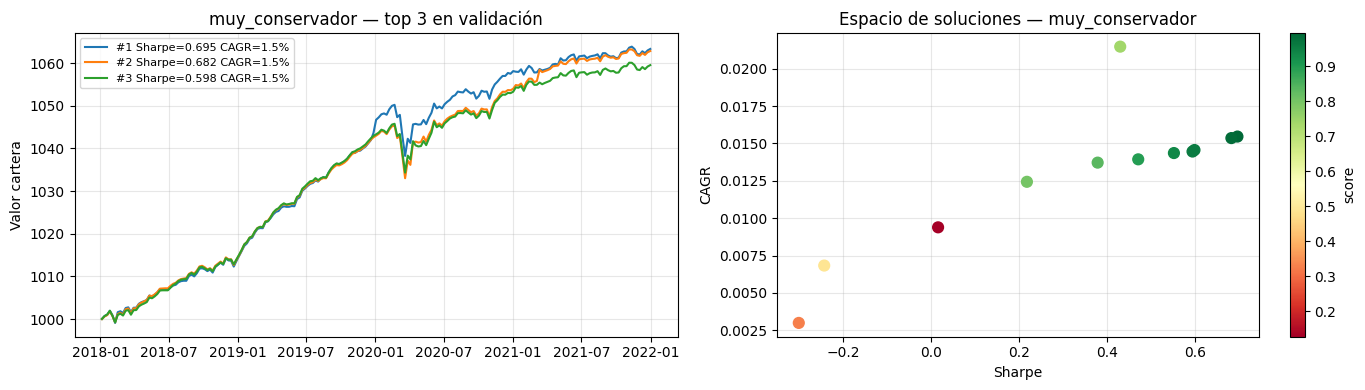


Top configs:
 ranking               config_id    score   sharpe     cagr  max_drawdown  tau  lr_actor  lr_criticos  lambda_varianza  lambda_correlacion
       1 muy_conservador_cfg_012 0.995254 0.695268 0.015463     -0.011408 0.05    0.0003       0.0003             0.55                 0.1
       2 muy_conservador_cfg_001 0.986680 0.681538 0.015360     -0.011805 0.02    0.0001       0.0003             0.25                 0.1
       3 muy_conservador_cfg_011 0.959646 0.597690 0.014561     -0.010945 0.05    0.0003       0.0003             0.40                 0.1


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Curvas de valor — top-K
ax = axes[0]
top_ids = resumen_mc.head(TOP_K)["config_id"].tolist()
for i, cid in enumerate(top_ids):
    if cid in curvas_mc and not curvas_mc[cid].empty:
        row = resumen_mc[resumen_mc["config_id"] == cid].iloc[0]
        label = f"#{i+1} Sharpe={row['sharpe']:.3f} CAGR={row['cagr']:.1%}"
        ax.plot(curvas_mc[cid].index, curvas_mc[cid].values, lw=1.5, label=label)
ax.set_title(f"muy_conservador — top {TOP_K} en validación")
ax.set_ylabel("Valor cartera")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Scatter Sharpe vs CAGR
ax = axes[1]
sc = ax.scatter(
    resumen_mc["sharpe"], resumen_mc["cagr"],
    c=resumen_mc["score"], cmap="RdYlGn", s=60, zorder=3,
)
plt.colorbar(sc, ax=ax, label="score")
ax.set_xlabel("Sharpe")
ax.set_ylabel("CAGR")
ax.set_title("Espacio de soluciones — muy_conservador")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTop configs:")
print(resumen_mc[["ranking", "config_id", "score", "sharpe", "cagr", "max_drawdown",
                  "tau", "lr_actor", "lr_criticos", "lambda_varianza", "lambda_correlacion"]].head(TOP_K).to_string(index=False))

---
# Fase 2 — conservador (riesgo = 0.30)

In [12]:
perfil_c = "conservador"
resumen_c, curvas_c, agentes_c = run_grid_perfil(perfil_c, PERFILES_RIESGO[perfil_c])

[conservador] Config 1/12 — conservador_cfg_001
  tau=0.02 | lr_actor=0.0001 | lr_criticos=0.0003 | lambda_varianza=0.15 | lambda_correlacion=0.1
[DIAGNÓSTICO INICIAL]
  mu: min=-2.0261  max=-0.0209  media=-1.8845
  std: min=0.3679  max=0.3679  media=0.3679
  log_prob: -11.3144  (target_entropy=-8.0000)
  residual inicial: -3.3144  (>0 → alpha sube, <0 → alpha baja)
  accion suma: 1.000000
  peso_cash inicial: 0.0828
retorno=-0.024050 | pen_total=+0.094146 | reward=-0.119197 | dd=0.3974 | vol=0.023765 | cash=0.000 | riesgo=0.30 || pen_dd=0.000000 | pen_varianza=0.023681 | pen_correlacion=0.048978 | pen_concentracion=0.017687 | pen_turn=0.003800 | 
retorno=+0.000704 | pen_total=+0.000014 | reward=+0.000688 | dd=0.0000 | vol=0.000631 | cash=0.931 | riesgo=0.30 || pen_dd=0.000000 | pen_varianza=0.000005 | pen_correlacion=0.000000 | pen_concentracion=0.000000 | pen_turn=0.000009 | 
retorno=-0.000724 | pen_total=+0.002728 | reward=-0.003455 | dd=0.0007 | vol=0.012375 | cash=0.934 | riesgo=0

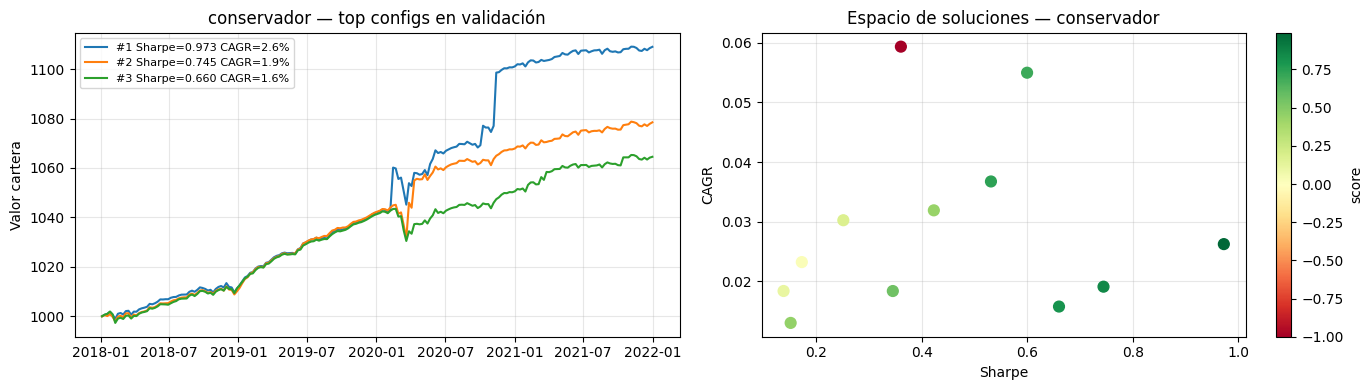

 ranking           config_id    score   sharpe     cagr  max_drawdown  tau  lr_actor  lr_criticos  lambda_varianza  lambda_correlacion
       1 conservador_cfg_012 0.990057 0.972541 0.026238     -0.014156 0.05    0.0003       0.0003             0.35                 0.1
       2 conservador_cfg_004 0.857418 0.744550 0.019102     -0.013114 0.02    0.0003       0.0003             0.15                 0.1
       3 conservador_cfg_009 0.809355 0.660220 0.015770     -0.012470 0.05    0.0001       0.0003             0.35                 0.1


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
top_ids = resumen_c.head(TOP_K)["config_id"].tolist()
for i, cid in enumerate(top_ids):
    if cid in curvas_c and not curvas_c[cid].empty:
        row = resumen_c[resumen_c["config_id"] == cid].iloc[0]
        ax.plot(curvas_c[cid].index, curvas_c[cid].values, lw=1.5,
                label=f"#{i+1} Sharpe={row['sharpe']:.3f} CAGR={row['cagr']:.1%}")
ax.set_title("conservador — top configs en validación")
ax.set_ylabel("Valor cartera")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax = axes[1]
sc = ax.scatter(resumen_c["sharpe"], resumen_c["cagr"],
                c=resumen_c["score"], cmap="RdYlGn", s=60, zorder=3)
plt.colorbar(sc, ax=ax, label="score")
ax.set_xlabel("Sharpe"); ax.set_ylabel("CAGR")
ax.set_title("Espacio de soluciones — conservador")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(resumen_c[["ranking", "config_id", "score", "sharpe", "cagr", "max_drawdown",
                 "tau", "lr_actor", "lr_criticos", "lambda_varianza", "lambda_correlacion"]].head(TOP_K).to_string(index=False))

---
# Fase 3 — normal (riesgo = 0.50)

In [14]:
perfil_n = "normal"
resumen_n, curvas_n, agentes_n = run_grid_perfil(perfil_n, PERFILES_RIESGO[perfil_n])

[normal] Config 1/12 — normal_cfg_001
  tau=0.02 | lr_actor=0.0001 | lr_criticos=0.0003 | lambda_varianza=0.15 | lambda_correlacion=0.1
[DIAGNÓSTICO INICIAL]
  mu: min=-2.0253  max=-0.0193  media=-1.8840
  std: min=0.3679  max=0.3679  media=0.3679
  log_prob: -11.3144  (target_entropy=-8.0000)
  residual inicial: -3.3144  (>0 → alpha sube, <0 → alpha baja)
  accion suma: 1.000000
  peso_cash inicial: 0.0829
retorno=-0.024050 | pen_total=+0.063012 | reward=-0.088062 | dd=0.3974 | vol=0.023765 | cash=0.000 | riesgo=0.50 || pen_dd=0.000000 | pen_varianza=0.017012 | pen_correlacion=0.030188 | pen_concentracion=0.012813 | pen_turn=0.003000 | 
retorno=+0.000898 | pen_total=+0.000014 | reward=+0.000882 | dd=0.0000 | vol=0.000783 | cash=0.919 | riesgo=0.50 || pen_dd=0.000000 | pen_varianza=0.000005 | pen_correlacion=0.000000 | pen_concentracion=0.000000 | pen_turn=0.000008 | 
retorno=-0.002670 | pen_total=+0.003736 | reward=-0.006442 | dd=0.0027 | vol=0.008706 | cash=0.529 | riesgo=0.50 || pen

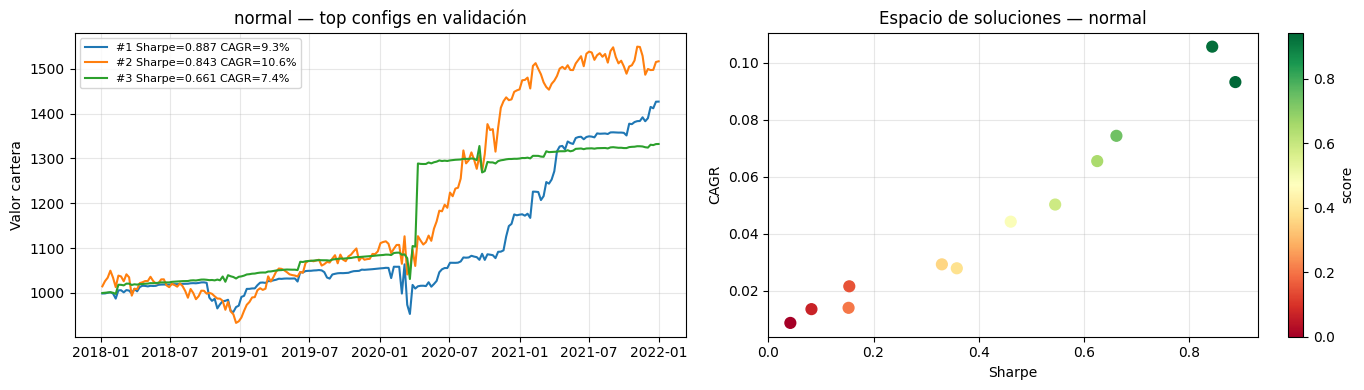

 ranking      config_id    score   sharpe     cagr  max_drawdown  tau  lr_actor  lr_criticos  lambda_varianza  lambda_correlacion
       1 normal_cfg_004 0.941820 0.887371 0.093282     -0.104116 0.02    0.0003       0.0003             0.15                 0.1
       2 normal_cfg_007 0.927815 0.843407 0.105730     -0.111038 0.05    0.0001       0.0003             0.15                 0.1
       3 normal_cfg_006 0.739337 0.661408 0.074402     -0.054024 0.02    0.0003       0.0003             0.35                 0.1


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
top_ids = resumen_n.head(TOP_K)["config_id"].tolist()
for i, cid in enumerate(top_ids):
    if cid in curvas_n and not curvas_n[cid].empty:
        row = resumen_n[resumen_n["config_id"] == cid].iloc[0]
        ax.plot(curvas_n[cid].index, curvas_n[cid].values, lw=1.5,
                label=f"#{i+1} Sharpe={row['sharpe']:.3f} CAGR={row['cagr']:.1%}")
ax.set_title("normal — top configs en validación")
ax.set_ylabel("Valor cartera")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax = axes[1]
sc = ax.scatter(resumen_n["sharpe"], resumen_n["cagr"],
                c=resumen_n["score"], cmap="RdYlGn", s=60, zorder=3)
plt.colorbar(sc, ax=ax, label="score")
ax.set_xlabel("Sharpe"); ax.set_ylabel("CAGR")
ax.set_title("Espacio de soluciones — normal")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(resumen_n[["ranking", "config_id", "score", "sharpe", "cagr", "max_drawdown",
                 "tau", "lr_actor", "lr_criticos", "lambda_varianza", "lambda_correlacion"]].head(TOP_K).to_string(index=False))

---
# Fase 4 — arriesgado (riesgo = 0.70)

In [16]:
perfil_a = "arriesgado"
resumen_a, curvas_a, agentes_a = run_grid_perfil(perfil_a, PERFILES_RIESGO[perfil_a])

[arriesgado] Config 1/16 — arriesgado_cfg_001
  tau=0.02 | lr_actor=0.0001 | lr_criticos=0.0003 | lambda_varianza=0.08 | lambda_correlacion=0.05
[DIAGNÓSTICO INICIAL]
  mu: min=-2.0241  max=-0.0172  media=-1.8835
  std: min=0.3679  max=0.3679  media=0.3679
  log_prob: -11.3144  (target_entropy=-8.0000)
  residual inicial: -3.3144  (>0 → alpha sube, <0 → alpha baja)
  accion suma: 1.000000
  peso_cash inicial: 0.0829
retorno=-0.024050 | pen_total=+0.023442 | reward=-0.048492 | dd=0.3974 | vol=0.023765 | cash=0.000 | riesgo=0.70 || pen_dd=0.000000 | pen_varianza=0.005516 | pen_correlacion=0.007789 | pen_concentracion=0.007938 | pen_turn=0.002200 | 
retorno=+0.007373 | pen_total=+0.000318 | reward=+0.007043 | dd=0.0393 | vol=0.009787 | cash=0.011 | riesgo=0.70 || pen_dd=0.000000 | pen_varianza=0.000292 | pen_correlacion=0.000000 | pen_concentracion=0.000000 | pen_turn=0.000026 | 
retorno=-0.015538 | pen_total=+0.004867 | reward=-0.020411 | dd=0.0155 | vol=0.028523 | cash=0.004 | riesgo=0.

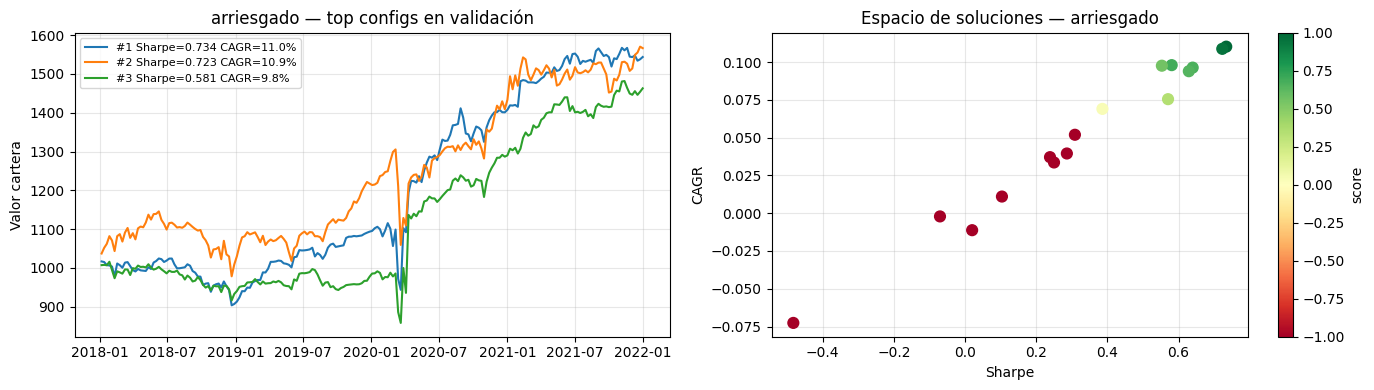

 ranking          config_id    score   sharpe     cagr  max_drawdown  tau  lr_actor  lr_criticos  lambda_varianza  lambda_correlacion
       1 arriesgado_cfg_003 1.000000 0.733967 0.110169     -0.154266 0.02    0.0001       0.0003             0.18                0.05
       2 arriesgado_cfg_002 0.950620 0.722829 0.108721     -0.188778 0.02    0.0001       0.0003             0.12                0.05
       3 arriesgado_cfg_009 0.688935 0.580716 0.097935     -0.155358 0.03    0.0001       0.0003             0.08                0.05


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
top_ids = resumen_a.head(TOP_K)["config_id"].tolist()
for i, cid in enumerate(top_ids):
    if cid in curvas_a and not curvas_a[cid].empty:
        row = resumen_a[resumen_a["config_id"] == cid].iloc[0]
        ax.plot(curvas_a[cid].index, curvas_a[cid].values, lw=1.5,
                label=f"#{i+1} Sharpe={row['sharpe']:.3f} CAGR={row['cagr']:.1%}")
ax.set_title("arriesgado — top configs en validación")
ax.set_ylabel("Valor cartera")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax = axes[1]
sc = ax.scatter(resumen_a["sharpe"], resumen_a["cagr"],
                c=resumen_a["score"], cmap="RdYlGn", s=60, zorder=3)
plt.colorbar(sc, ax=ax, label="score")
ax.set_xlabel("Sharpe"); ax.set_ylabel("CAGR")
ax.set_title("Espacio de soluciones — arriesgado")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(resumen_a[["ranking", "config_id", "score", "sharpe", "cagr", "max_drawdown",
                 "tau", "lr_actor", "lr_criticos", "lambda_varianza", "lambda_correlacion"]].head(TOP_K).to_string(index=False))

---
# Fase 5 — muy_arriesgado (riesgo = 0.90)

In [18]:
perfil_ma = "muy_arriesgado"
resumen_ma, curvas_ma, agentes_ma = run_grid_perfil(perfil_ma, PERFILES_RIESGO[perfil_ma])

[muy_arriesgado] Config 1/12 — muy_arriesgado_cfg_001
  tau=0.02 | lr_actor=0.0001 | lr_criticos=0.0003 | lambda_varianza=0.02 | lambda_correlacion=0.02
[DIAGNÓSTICO INICIAL]
  mu: min=-2.0226  max=-0.0144  media=-1.8834
  std: min=0.3679  max=0.3679  media=0.3679
  log_prob: -11.3144  (target_entropy=-8.0000)
  residual inicial: -3.3144  (>0 → alpha sube, <0 → alpha baja)
  accion suma: 1.000000
  peso_cash inicial: 0.0829
retorno=-0.024050 | pen_total=+0.005982 | reward=-0.031032 | dd=0.3974 | vol=0.023765 | cash=0.000 | riesgo=0.90 || pen_dd=0.000000 | pen_varianza=0.000490 | pen_correlacion=0.001030 | pen_concentracion=0.003062 | pen_turn=0.001400 | 
retorno=+0.024047 | pen_total=+0.000826 | reward=+0.023190 | dd=0.0108 | vol=0.014971 | cash=0.012 | riesgo=0.90 || pen_dd=0.000000 | pen_varianza=0.000052 | pen_correlacion=0.000187 | pen_concentracion=0.000545 | pen_turn=0.000043 | 
retorno=-0.008191 | pen_total=+0.000109 | reward=-0.008329 | dd=0.0082 | vol=0.018792 | cash=0.005 | r

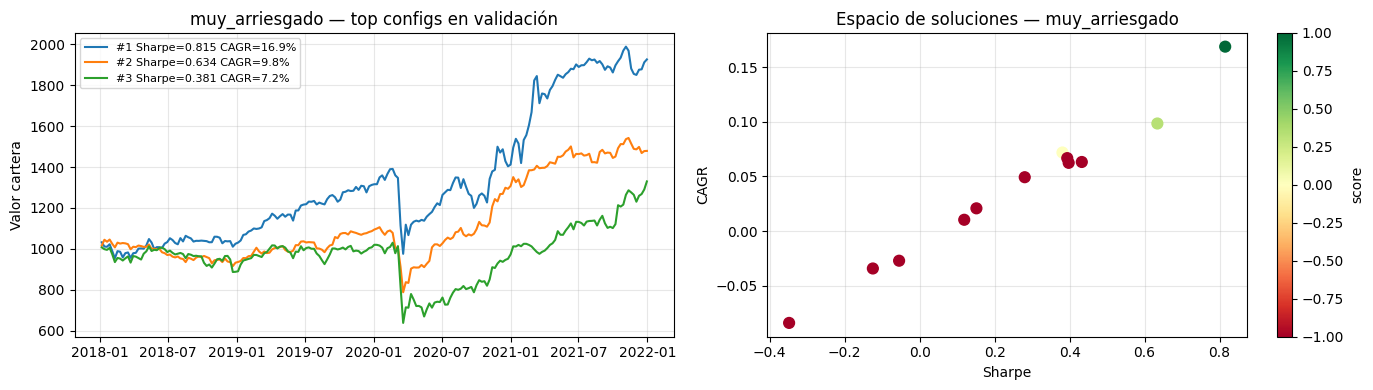

 ranking              config_id    score   sharpe     cagr  max_drawdown  tau  lr_actor  lr_criticos  lambda_varianza  lambda_correlacion
       1 muy_arriesgado_cfg_002 1.000000 0.815077 0.168680     -0.298272 0.02    0.0001       0.0003             0.05                0.02
       2 muy_arriesgado_cfg_004 0.335805 0.634163 0.098428     -0.287465 0.02    0.0003       0.0003             0.02                0.02
       3 muy_arriesgado_cfg_012 0.000000 0.380997 0.071920     -0.380412 0.05    0.0003       0.0003             0.08                0.02


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
top_ids = resumen_ma.head(TOP_K)["config_id"].tolist()
for i, cid in enumerate(top_ids):
    if cid in curvas_ma and not curvas_ma[cid].empty:
        row = resumen_ma[resumen_ma["config_id"] == cid].iloc[0]
        ax.plot(curvas_ma[cid].index, curvas_ma[cid].values, lw=1.5,
                label=f"#{i+1} Sharpe={row['sharpe']:.3f} CAGR={row['cagr']:.1%}")
ax.set_title("muy_arriesgado — top configs en validación")
ax.set_ylabel("Valor cartera")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax = axes[1]
sc = ax.scatter(resumen_ma["sharpe"], resumen_ma["cagr"],
                c=resumen_ma["score"], cmap="RdYlGn", s=60, zorder=3)
plt.colorbar(sc, ax=ax, label="score")
ax.set_xlabel("Sharpe"); ax.set_ylabel("CAGR")
ax.set_title("Espacio de soluciones — muy_arriesgado")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(resumen_ma[["ranking", "config_id", "score", "sharpe", "cagr", "max_drawdown",
                  "tau", "lr_actor", "lr_criticos", "lambda_varianza", "lambda_correlacion"]].head(TOP_K).to_string(index=False))

---
# Verificación cruzada de jerarquía

Comprueba que los ganadores de cada perfil cumplen la jerarquía esperada en CAGR, Sharpe y Vol.  
Un perfil más arriesgado debería tener mayor CAGR y mayor Vol que uno más conservador.

In [20]:
ORDEN_PERFILES = ["muy_conservador", "conservador", "normal", "arriesgado", "muy_arriesgado"]

resumenes = {
    "muy_conservador": resumen_mc,
    "conservador":     resumen_c,
    "normal":          resumen_n,
    "arriesgado":      resumen_a,
    "muy_arriesgado":  resumen_ma,
}

# Extraer métricas del ganador (rank=1) de cada perfil
ganadores = {}
for perfil in ORDEN_PERFILES:
    best = resumenes[perfil].iloc[0]
    ganadores[perfil] = {
        "config_id":   best["config_id"],
        "score":       best["score"],
        "sharpe":      best["sharpe"],
        "cagr":        best["cagr"],
        "max_drawdown": best["max_drawdown"],
        "vol":         best["vol"],
    }

# Tabla resumen
df_ganadores = pd.DataFrame(ganadores).T[[
    "config_id", "score", "sharpe", "cagr", "max_drawdown", "vol"
]]
df_ganadores.index.name = "perfil"

print("=" * 80)
print("RESUMEN FINAL — VALIDACIÓN")
print(df_ganadores.to_string(
    float_format=lambda x: f"{x:.4f}" if abs(x) < 100 else f"{x:.2f}"
))

# Verificar jerarquías
print("\n" + "=" * 80)
print("VERIFICACIÓN DE JERARQUÍAS")
print("-" * 40)

metricas_jerarquia = ["cagr", "vol"]
jerarquia_ok = True

for metrica in metricas_jerarquia:
    valores = [ganadores[p][metrica] for p in ORDEN_PERFILES]
    violaciones = []
    for i in range(len(ORDEN_PERFILES) - 1):
        p_bajo = ORDEN_PERFILES[i]
        p_alto = ORDEN_PERFILES[i + 1]
        if not np.isnan(valores[i]) and not np.isnan(valores[i+1]):
            if valores[i] >= valores[i+1]:
                violaciones.append(f"{p_bajo} ({valores[i]:.4f}) >= {p_alto} ({valores[i+1]:.4f})")
                jerarquia_ok = False
    if violaciones:
        print(f"  ⚠️  {metrica.upper()} — violaciones:")
        for v in violaciones:
            print(f"       {v}")
    else:
        print(f"  ✅  {metrica.upper()} — jerarquía correcta")

print()
if jerarquia_ok:
    print("✅ Jerarquía completa verificada")
else:
    print("⚠️  Hay violaciones — revisa los lambdas de los perfiles afectados")

RESUMEN FINAL — VALIDACIÓN
                               config_id  score sharpe   cagr max_drawdown    vol
perfil                                                                           
muy_conservador  muy_conservador_cfg_012 0.9953 0.6953 0.0155      -0.0114 0.0068
conservador          conservador_cfg_012 0.9901 0.9725 0.0262      -0.0142 0.0157
normal                    normal_cfg_004 0.9418 0.8874 0.0933      -0.1041 0.0933
arriesgado            arriesgado_cfg_003 1.0000 0.7340 0.1102      -0.1543 0.1410
muy_arriesgado    muy_arriesgado_cfg_002 1.0000 0.8151 0.1687      -0.2983 0.2043

VERIFICACIÓN DE JERARQUÍAS
----------------------------------------
  ✅  CAGR — jerarquía correcta
  ✅  VOL — jerarquía correcta

✅ Jerarquía completa verificada


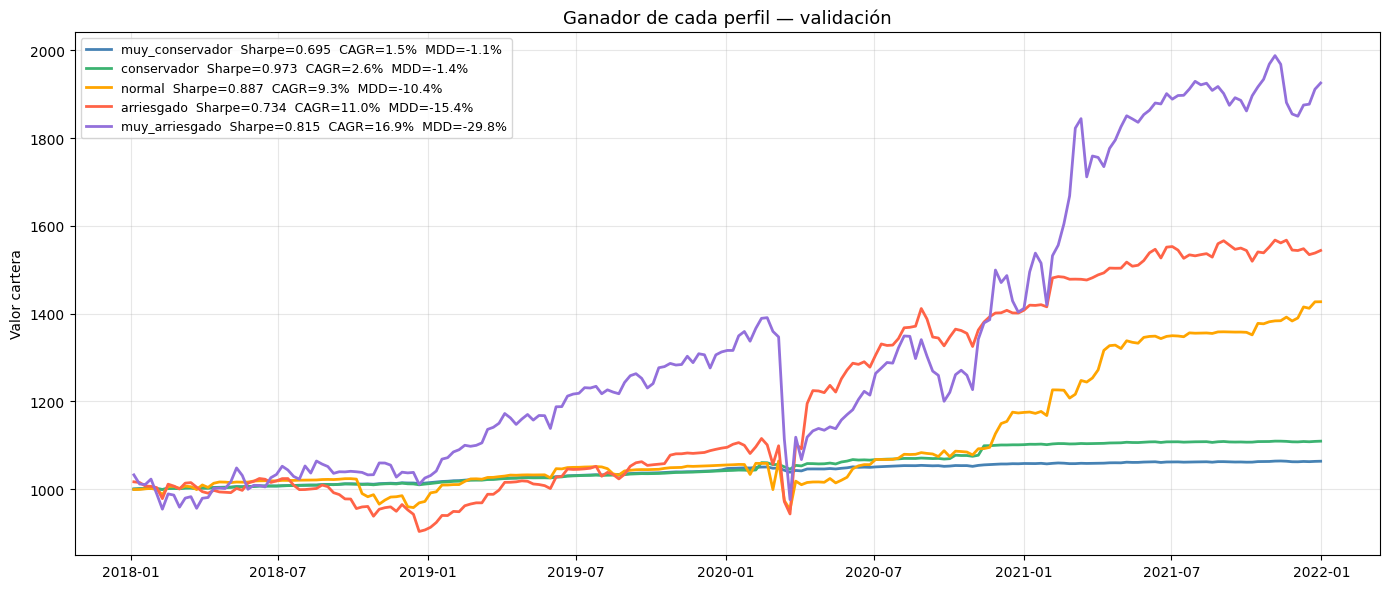

In [21]:
# Gráfico comparativo: curvas de los 5 ganadores superpuestas
todas_curvas = {
    "muy_conservador": curvas_mc,
    "conservador":     curvas_c,
    "normal":          curvas_n,
    "arriesgado":      curvas_a,
    "muy_arriesgado":  curvas_ma,
}
colores = {
    "muy_conservador": "steelblue",
    "conservador":     "mediumseagreen",
    "normal":          "orange",
    "arriesgado":      "tomato",
    "muy_arriesgado":  "mediumpurple",
}

fig, ax = plt.subplots(figsize=(14, 6))
for perfil in ORDEN_PERFILES:
    best_id = resumenes[perfil].iloc[0]["config_id"]
    serie = todas_curvas[perfil].get(best_id)
    if serie is not None and not serie.empty:
        g = ganadores[perfil]
        label = (
            f"{perfil}  "
            f"Sharpe={g['sharpe']:.3f}  "
            f"CAGR={g['cagr']:.1%}  "
            f"MDD={g['max_drawdown']:.1%}"
        )
        ax.plot(serie.index, serie.values, lw=2, color=colores[perfil], label=label)

ax.set_title("Ganador de cada perfil — validación", fontsize=13)
ax.set_ylabel("Valor cartera")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Persistencia — guardar configuraciones ganadoras

In [26]:
output_path = PROJECT_ROOT / "config_ganadora_hpo.json"

PARAMS_GUARDAR = [
    "riesgo", "gamma", "tau", "lr_actor", "lr_criticos", "lr_alpha",
    "tamano_batch", "tamano_buffer", "pasos_warmup", "reward_scale",
    "target_entropy", "gamma",
    "lambda_dd", "lambda_varianza", "lambda_correlacion",
]

configs_json: Dict[str, Dict] = {}

for perfil in ORDEN_PERFILES:
    best = resumenes[perfil].iloc[0]
    cfg = copy.deepcopy(BASE_CONFIG)
    cfg["riesgo"] = float(PERFILES_RIESGO[perfil])

    # Sobrescribir con los valores ganadores
    for p in ["tau", "lr_actor", "lr_criticos", "lambda_dd", "lambda_varianza", "lambda_correlacion"]:
        if p in best.index and not pd.isna(best[p]):
            cfg[p] = float(best[p])

    # Serializar solo lo necesario para Test
    configs_json[perfil] = {
        k: (float(v) if isinstance(v, (np.floating, np.integer, float, int)) else v)
        for k, v in cfg.items()
        if k in PARAMS_GUARDAR
    }
    # Añadir métricas de validación para referencia
    configs_json[perfil]["_val_sharpe"]      = float(best["sharpe"])
    configs_json[perfil]["_val_cagr"]        = float(best["cagr"])
    configs_json[perfil]["_val_max_drawdown"]= float(best["max_drawdown"])
    configs_json[perfil]["_val_score"]       = float(best["score"])

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(configs_json, f, indent=2, ensure_ascii=False)

print(f"✅ Configuraciones guardadas en: {output_path}")
print()

campos_mostrar = ["riesgo", "tau", "lr_actor", "lr_criticos",
                  "lambda_dd", "lambda_varianza", "lambda_correlacion",
                  "_val_sharpe", "_val_cagr", "_val_max_drawdown"]
for perfil, cfg in configs_json.items():
    print(f"  [{perfil}]")
    for k in campos_mostrar:
        if k in cfg:
            print(f"    {k:35s} = {cfg[k]}")
    print()

✅ Configuraciones guardadas en: /Users/inigo/Optimizaci-n-din-mica-de-carteras-mediante-Deep-Reinforcement-Learning/config_ganadora_hpo.json

  [muy_conservador]
    riesgo                              = 0.1
    tau                                 = 0.05
    lr_actor                            = 0.0003
    lr_criticos                         = 0.0003
    lambda_varianza                     = 0.55
    lambda_correlacion                  = 0.1
    _val_sharpe                         = 0.6952682756922676
    _val_cagr                           = 0.015462785162265291
    _val_max_drawdown                   = -0.01140837118110094

  [conservador]
    riesgo                              = 0.3
    tau                                 = 0.05
    lr_actor                            = 0.0003
    lr_criticos                         = 0.0003
    lambda_varianza                     = 0.35
    lambda_correlacion                  = 0.1
    _val_sharpe                         = 0.9725412764032134
    _

In [25]:
# ------------------------------------------------------------------
# Cómo usar las configs en Test.py
# ------------------------------------------------------------------
print("""
# En Test.py, cargar y reentrenar cada perfil con sus hiperparámetros ganadores:

import json
with open("config_ganadora_hpo.json") as f:
    configs = json.load(f)

for perfil, cfg in configs.items():
    riesgo = cfg["riesgo"]
    entorno_full = construir_entorno(
        datos_estado=datos_estado_train,  # o train+val concatenados
        retornos=retornos_train,
        rf_semanal=rf_semanal_train,
        riesgo=riesgo,
        cfg=cfg,
        covarianzas_iniciales=cov_train,
    )
    cfg_train = build_train_config({**cfg, "pasos_totales": 200_000})
    history, agente = entrenar_sac(entorno_full, cfg_train, devolver_agente=True, riesgo=riesgo)
    # ... evaluar en test
""")


# En Test.py, cargar y reentrenar cada perfil con sus hiperparámetros ganadores:

import json
with open("config_ganadora_hpo.json") as f:
    configs = json.load(f)

for perfil, cfg in configs.items():
    riesgo = cfg["riesgo"]
    entorno_full = construir_entorno(
        datos_estado=datos_estado_train,  # o train+val concatenados
        retornos=retornos_train,
        rf_semanal=rf_semanal_train,
        riesgo=riesgo,
        cfg=cfg,
        covarianzas_iniciales=cov_train,
    )
    cfg_train = build_train_config({**cfg, "pasos_totales": 200_000})
    history, agente = entrenar_sac(entorno_full, cfg_train, devolver_agente=True, riesgo=riesgo)
    # ... evaluar en test

